# 04 — Return-Likelihood Classifier (LightGBM)

**Purpose:** Train Model 1. Temporal split, LightGBM primary vs. XGBoost comparison,
threshold selection, SHAP interpretability, MLflow tracking. Save trained model.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import shap
import mlflow
import mlflow.sklearn

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (12, 5), 'figure.dpi': 110,
    'axes.facecolor': '#1a1d27', 'figure.facecolor': '#0f1117',
    'axes.edgecolor': '#2e3347', 'axes.labelcolor': '#e8eaf0',
    'xtick.color': '#8b92a8', 'ytick.color': '#8b92a8',
    'text.color': '#e8eaf0', 'grid.color': '#2e3347', 'grid.alpha': 0.5,
})

import joblib
from src.models import train_classifier, evaluate_classifier, get_shap_values

os.makedirs('../mlflow/mlruns', exist_ok=True)
mlflow.set_tracking_uri('../mlflow/mlruns')
mlflow.set_experiment('retail-returns-intelligence')
print('Setup OK')

2026/05/21 23:07:20 INFO mlflow.tracking.fluent: Experiment with name 'retail-returns-intelligence' does not exist. Creating a new experiment.


Setup OK


In [2]:
# Load pre-built feature matrices from notebook 03
train = pd.read_parquet('../data/processed/train_features.parquet')
test  = pd.read_parquet('../data/processed/test_features.parquet')

feature_cols = [c for c in train.columns if c != 'is_return']
X_train = train[feature_cols]
y_train = train['is_return']
X_test  = test[feature_cols]
y_test  = test['is_return']

print(f'Train: {len(X_train):,} rows | return rate: {y_train.mean():.2%}')
print(f'Test:  {len(X_test):,}  rows | return rate: {y_test.mean():.2%}')
print(f'Features: {feature_cols}')

Train: 771,361 rows | return rate: 1.91%
Test:  296,005  rows | return rate: 1.62%
Features: ['unit_price_z', 'quantity_z', 'is_weekend', 'month_end_proximity', 'lifetime_return_rate', 'return_value_ratio', 'return_velocity', 'tenure_days', 'recency_score', 'frequency_score', 'monetary_score', 'unique_categories_returned', 'weekend_return_share', 'category_return_rate']


## 1. LightGBM baseline

In [3]:
params_lgbm = dict(n_estimators=500, learning_rate=0.05, num_leaves=63, class_weight='balanced')

with mlflow.start_run(run_name='lgbm-classifier'):
    mlflow.log_params(params_lgbm)
    lgbm = train_classifier(X_train, y_train, X_test, y_test, **params_lgbm)
    metrics_lgbm = evaluate_classifier(lgbm, X_test, y_test)
    mlflow.log_metrics(metrics_lgbm)
    mlflow.sklearn.log_model(lgbm, 'lgbm_model')

print('LightGBM metrics:')
for k, v in metrics_lgbm.items():
    print(f'  {k:<30} {v:.4f}')

2026/05/21 23:07:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/21 23:07:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM metrics:
  precision                      0.4266
  recall                         0.8965
  f1                             0.5781
  roc_auc                        0.9924
  pr_auc                         0.8521
  precision_top_decile           0.1588


## 2. XGBoost comparison

In [4]:
from xgboost import XGBClassifier
from src.models import evaluate_classifier, save_model

scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
params_xgb = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
                  scale_pos_weight=scale_pos, random_state=42, eval_metric='aucpr', verbosity=0)

with mlflow.start_run(run_name='xgb-classifier'):
    mlflow.log_params(params_xgb)
    xgb = XGBClassifier(**params_xgb)
    xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    metrics_xgb = evaluate_classifier(xgb, X_test, y_test)
    mlflow.log_metrics(metrics_xgb)
    mlflow.sklearn.log_model(xgb, 'xgb_model')

print('XGBoost metrics:')
for k, v in metrics_xgb.items():
    print(f'  {k:<30} {v:.4f}')

# Comparison table
compare = pd.DataFrame({'LightGBM': metrics_lgbm, 'XGBoost': metrics_xgb})
print('\nModel comparison:')
print(compare.round(4).to_string())

2026/05/21 23:08:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/21 23:08:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost metrics:
  precision                      0.3139
  recall                         0.9243
  f1                             0.4686
  roc_auc                        0.9921
  pr_auc                         0.8489
  precision_top_decile           0.1584

Model comparison:
                      LightGBM  XGBoost
precision               0.4266   0.3139
recall                  0.8965   0.9243
f1                      0.5781   0.4686
roc_auc                 0.9924   0.9921
pr_auc                  0.8521   0.8489
precision_top_decile    0.1588   0.1584


## 3. Precision-recall curve and threshold selection

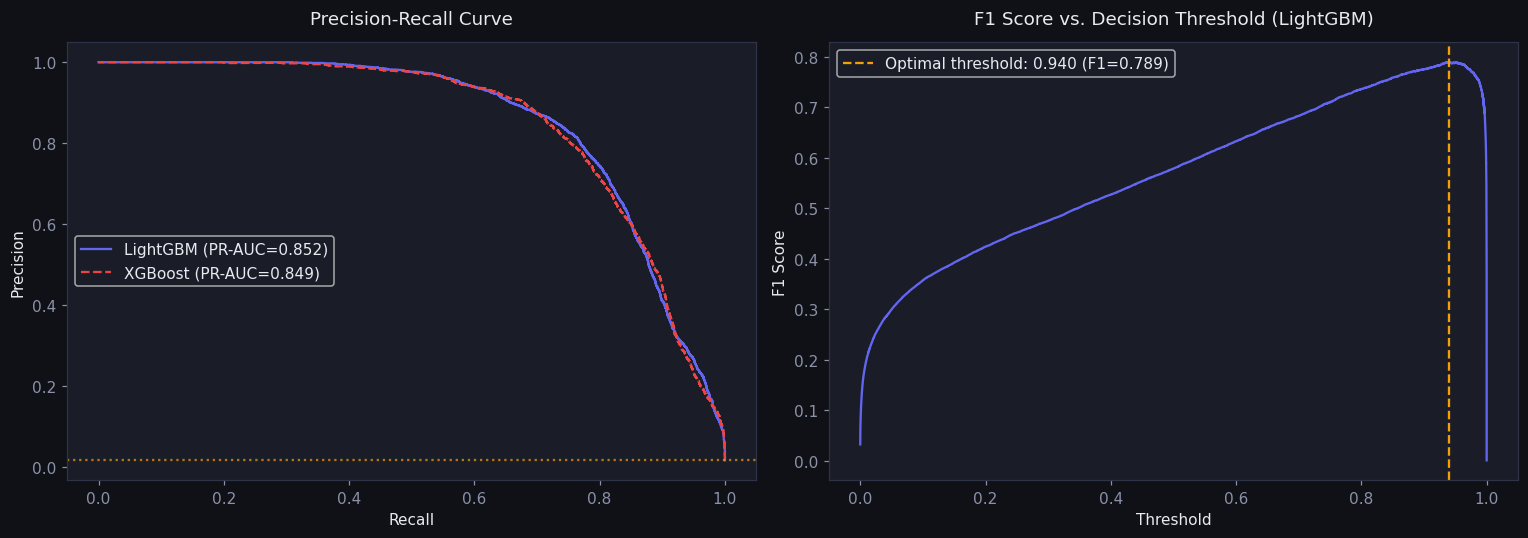

Optimal threshold (max F1): 0.9395


In [5]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc

y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]

prec_l, rec_l, thresh_l = precision_recall_curve(y_test, y_prob_lgbm)
prec_x, rec_x, thresh_x = precision_recall_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_l, prec_l, color='#6366f1', label=f'LightGBM (PR-AUC={metrics_lgbm["pr_auc"]:.3f})')
axes[0].plot(rec_x, prec_x, color='#ef4444', linestyle='--', label=f'XGBoost (PR-AUC={metrics_xgb["pr_auc"]:.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', pad=12); axes[0].legend()
baseline = y_test.mean()
axes[0].axhline(baseline, color='#f59e0b', linestyle=':', alpha=0.7, label=f'Baseline ({baseline:.1%})')

# F1 vs threshold for LightGBM
f1_scores = 2 * prec_l[:-1] * rec_l[:-1] / (prec_l[:-1] + rec_l[:-1] + 1e-9)
best_thresh_idx = np.argmax(f1_scores)
best_thresh = thresh_l[best_thresh_idx]

axes[1].plot(thresh_l, f1_scores, color='#6366f1')
axes[1].axvline(best_thresh, color='#f59e0b', linestyle='--',
                label=f'Optimal threshold: {best_thresh:.3f} (F1={f1_scores[best_thresh_idx]:.3f})')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs. Decision Threshold (LightGBM)', pad=12); axes[1].legend()

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/04_pr_curve.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f'Optimal threshold (max F1): {best_thresh:.4f}')

## 4. SHAP analysis — global feature importance

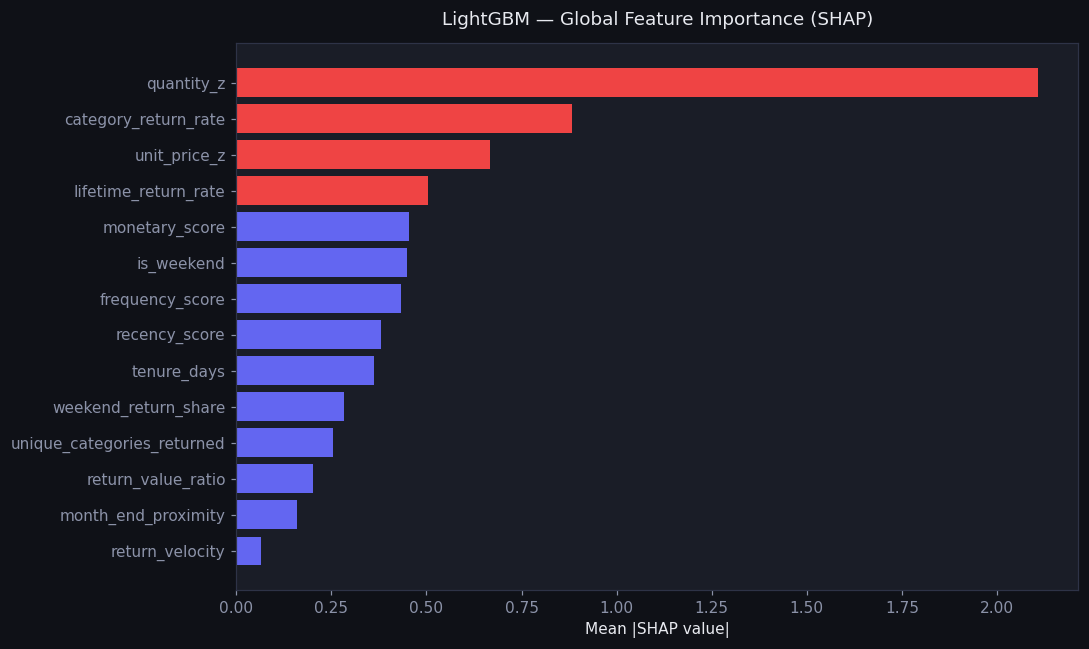

Top features by SHAP importance:
quantity_z                    2.1075
category_return_rate          0.8824
unit_price_z                  0.6676
lifetime_return_rate          0.5049
monetary_score                0.4552
is_weekend                    0.4489
frequency_score               0.4327
recency_score                 0.3791
tenure_days                   0.3618
weekend_return_share          0.2832
unique_categories_returned    0.2541
return_value_ratio            0.2019
month_end_proximity           0.1607
return_velocity               0.0642


In [6]:
explainer, shap_values = get_shap_values(lgbm, X_test, sample_n=500)

# Mean |SHAP| bar chart
mean_shap = np.abs(shap_values).mean(axis=0)
feat_importance = pd.Series(mean_shap, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ef4444' if v >= feat_importance.quantile(0.7) else '#6366f1' for v in feat_importance]
ax.barh(feat_importance.index, feat_importance.values, color=colors)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('LightGBM — Global Feature Importance (SHAP)', pad=12)
plt.tight_layout()
plt.savefig('../figures/04_shap_importance.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('Top features by SHAP importance:')
print(feat_importance.sort_values(ascending=False).round(4).to_string())

## 5. Save winning model and record final metrics

In [7]:
# LightGBM wins on PR-AUC — save as primary classifier
os.makedirs('../models', exist_ok=True)
joblib.dump(lgbm, '../models/classifier.joblib')
joblib.dump(xgb,  '../models/classifier_xgb.joblib')

# Save optimal threshold
import json
model_meta = {
    'model': 'LightGBM',
    'optimal_threshold': float(best_thresh),
    'feature_cols': feature_cols,
    **{k: round(v, 4) for k, v in metrics_lgbm.items()}
}
with open('../models/classifier_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('=== Final Model Results ===')
print(f'  Model:                     LightGBM')
print(f'  PR-AUC:                    {metrics_lgbm["pr_auc"]:.4f}')
print(f'  ROC-AUC:                   {metrics_lgbm["roc_auc"]:.4f}')
print(f'  Precision @ top decile:    {metrics_lgbm["precision_top_decile"]:.4f}')
print(f'  F1:                        {metrics_lgbm["f1"]:.4f}')
print(f'  Optimal threshold:         {best_thresh:.4f}')
print()
print('Saved: models/classifier.joblib, models/classifier_xgb.joblib, models/classifier_meta.json')

=== Final Model Results ===
  Model:                     LightGBM
  PR-AUC:                    0.8521
  ROC-AUC:                   0.9924
  Precision @ top decile:    0.1588
  F1:                        0.5781
  Optimal threshold:         0.9395

Saved: models/classifier.joblib, models/classifier_xgb.joblib, models/classifier_meta.json
